In [2]:
# SECTION 1 — LIBRARY IMPORTS & GLOBAL SETTINGS

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder,
    PolynomialFeatures,
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier,
    AdaBoostClassifier,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report,
)

from scipy.stats import randint, uniform, loguniform

import os, time, itertools

SEED = 42
np.random.seed(SEED)

In [3]:
TRAIN_PATH = "titanic/train.csv"
TEST_PATH = "titanic/test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print(train_raw.shape)
print(test_raw.shape)

train_raw.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_raw.info()

display(train_raw.describe(include="all"))

missing = train_raw.isnull().sum()
missing_pct = (missing / len(train_raw) * 100).round(2)

missing_df = pd.DataFrame({
    "count": missing,
    "pct": missing_pct
})

display(missing_df[missing_df["count"] > 0])

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


,count,pct
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


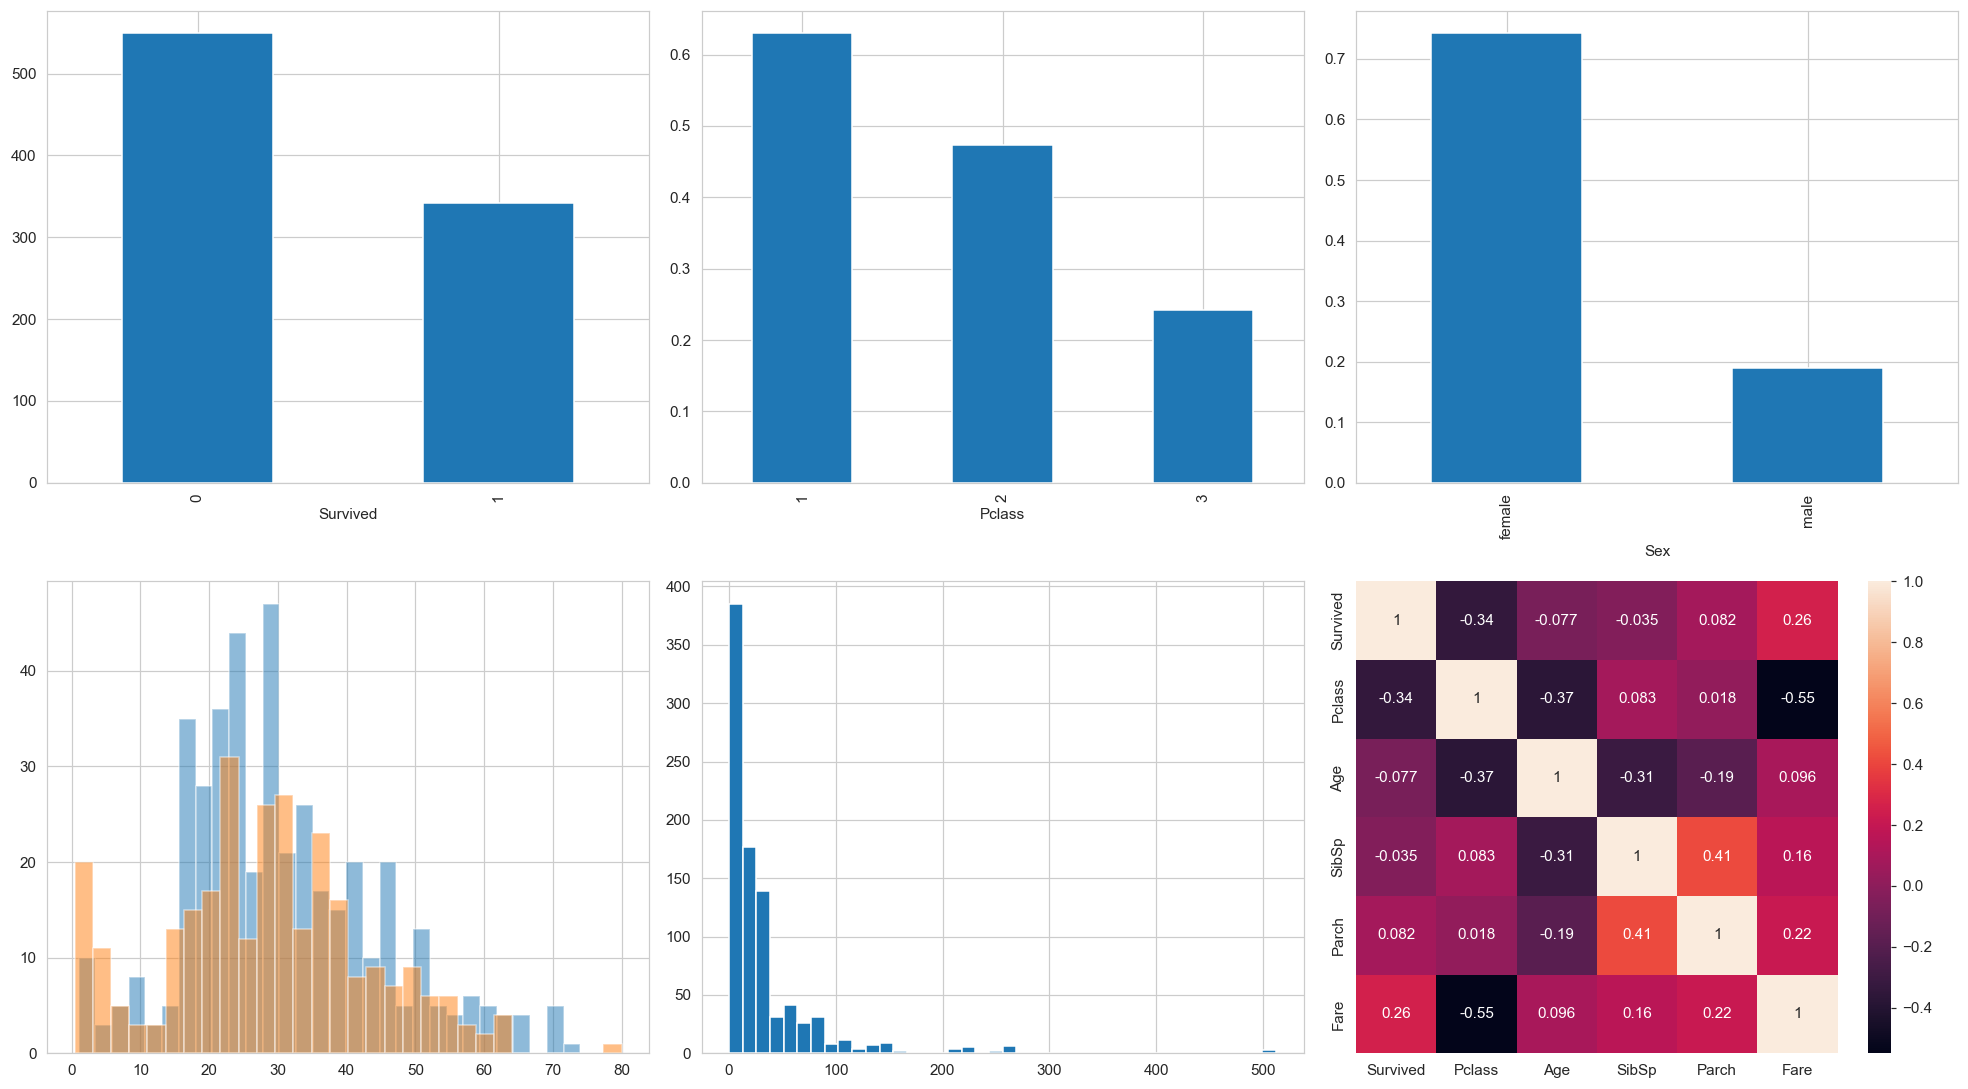

In [5]:
survival_counts = train_raw["Survived"].value_counts()

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Survival Count
survival_counts.plot(kind="bar", ax=axes[0,0])

# Survival by Class
train_raw.groupby("Pclass")["Survived"].mean().plot(
    kind="bar", ax=axes[0,1]
)

# Survival by Sex
train_raw.groupby("Sex")["Survived"].mean().plot(
    kind="bar", ax=axes[0,2]
)

# Age Distribution
train_raw[train_raw["Survived"]==0]["Age"].dropna().hist(
    bins=30, alpha=0.5, ax=axes[1,0]
)

train_raw[train_raw["Survived"]==1]["Age"].dropna().hist(
    bins=30, alpha=0.5, ax=axes[1,0]
)

# Fare Distribution
train_raw["Fare"].hist(
    bins=40,
    ax=axes[1,1]
)

# Correlation
corr_cols = ["Survived","Pclass","Age","SibSp","Parch","Fare"]
sns.heatmap(
    train_raw[corr_cols].corr(),
    annot=True,
    ax=axes[1,2]
)

plt.tight_layout()
plt.show()

In [6]:
def engineer_features(df):

    df = df.copy()

    df["Title"] = df["Name"].str.extract(
        r" ([A-Za-z]+)\.",
        expand=False
    )

    title_mapping = {
        "Mr":"Mr",
        "Mrs":"Mrs",
        "Miss":"Miss",
        "Master":"Master"
    }

    df["Title"] = (
        df["Title"]
        .map(title_mapping)
        .fillna("Rare")
    )

    df["FamilySize"] = (
        df["SibSp"] + df["Parch"] + 1
    )

    df["IsAlone"] = (
        df["FamilySize"] == 1
    ).astype(int)

    df["FamilyCategory"] = pd.cut(
        df["FamilySize"],
        bins=[0,1,4,20],
        labels=["Alone","Small","Large"]
    )

    df["Deck"] = (
        df["Cabin"]
        .str[0]
        .fillna("U")
    )

    deck_counts = df["Deck"].value_counts()
    rare_decks = deck_counts[deck_counts < 10].index

    df["Deck"] = df["Deck"].replace(
        rare_decks,
        "Rare"
    )

    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[0,12,18,35,60,120],
        labels=[
            "Child",
            "Teen",
            "YoungAdult",
            "Adult",
            "Senior"
        ]
    )

    df["FareBin"] = pd.qcut(
        df["Fare"],
        q=4,
        labels=["Q1","Q2","Q3","Q4"],
        duplicates="drop"
    )

    df["TicketPrefix"] = (
        df["Ticket"]
        .str.extract(r"^([A-Za-z./]+)")
    )

    df["TicketPrefix"] = (
        df["TicketPrefix"]
        .fillna("NUM")
    )

    prefix_counts = (
        df["TicketPrefix"]
        .value_counts()
    )

    rare_prefixes = (
        prefix_counts[prefix_counts < 10]
        .index
    )

    df["TicketPrefix"] = (
        df["TicketPrefix"]
        .replace(rare_prefixes,"Other")
    )

    return df

In [7]:
train = engineer_features(train_raw)
test = engineer_features(test_raw)

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FamilyCategory,Deck,AgeGroup,FareBin,TicketPrefix
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,Small,U,YoungAdult,Q1,A/
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,Small,C,Adult,Q4,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,Alone,U,YoungAdult,Q2,STON/O
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,Small,C,YoungAdult,Q4,NUM
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,Alone,U,YoungAdult,Q2,NUM


In [8]:
NUMERIC_FEATURES = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "Pclass"
]

CATEGORICAL_FEATURES = [
    "Sex",
    "Embarked",
    "Title",
    "FamilyCategory",
    "Deck",
    "AgeGroup",
    "FareBin",
    "TicketPrefix"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES)
])

In [9]:
X = train[
    NUMERIC_FEATURES +
    CATEGORICAL_FEATURES
]

y = train["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_test = test[
    NUMERIC_FEATURES +
    CATEGORICAL_FEATURES
]

In [10]:
X_train_pp = preprocessor.fit_transform(
    X_train,
    y_train
)

X_val_pp = preprocessor.transform(X_val)

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_pp, y_train)

baseline_acc = accuracy_score(
    y_val,
    baseline.predict(X_val_pp)
)

print(baseline_acc)

0.6145251396648045


In [11]:
def make_pipeline(clf):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

models = {
    "LogisticRegression":
        make_pipeline(
            LogisticRegression(
                max_iter=1000
            )
        ),

    "RandomForest":
        make_pipeline(
            RandomForestClassifier(
                n_estimators=200
            )
        ),

    "GradientBoosting":
        make_pipeline(
            GradientBoostingClassifier()
        ),

    "SVM":
        make_pipeline(
            SVC(probability=True)
        )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    results[name] = scores.mean()

results

{'LogisticRegression': np.float64(0.8226476680685456),
 'RandomForest': np.float64(0.8204004770573097),
 'GradientBoosting': np.float64(0.8383591739376058),
 'SVM': np.float64(0.8327600276191074)}

In [12]:
rf_grid = {
    "classifier__n_estimators":[300,500],
    "classifier__max_depth":[
        None,
        6,
        10
    ]
}

grid = GridSearchCV(
    make_pipeline(
        RandomForestClassifier()
    ),
    rf_grid,
    cv=cv,
    scoring="accuracy"
)

grid.fit(X,y)

best_rf = grid.best_estimator_

print(grid.best_score_)

0.8372544096415794


              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

0.846179183135705


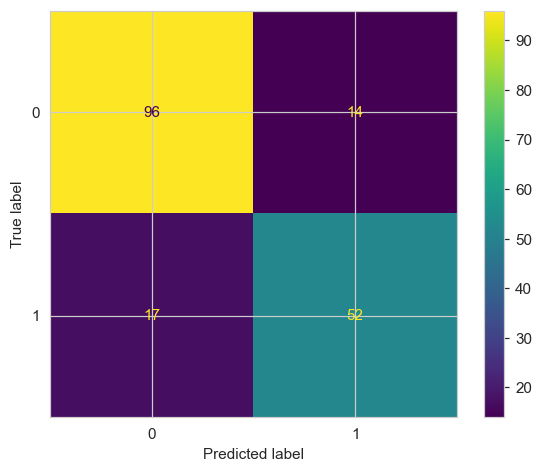

In [13]:
best_rf.fit(X_train, y_train)

preds = best_rf.predict(X_val)
probs = best_rf.predict_proba(X_val)[:,1]

print(
    classification_report(
        y_val,
        preds
    )
)

print(
    roc_auc_score(
        y_val,
        probs
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    preds
)

plt.show()

In [14]:
clf = best_rf.named_steps["classifier"]

feature_names = (
    best_rf.named_steps["preprocessor"]
    .get_feature_names_out()
)

fi = pd.DataFrame({
    "Feature":feature_names,
    "Importance":clf.feature_importances_
})

fi = fi.sort_values(
    "Importance",
    ascending=False
)

display(fi.head(20))

,Feature,Importance
14,cat__Title_Mr,0.149279
7,cat__Sex_female,0.134610
8,cat__Sex_male,0.120263
1,num__Fare,0.081448
6,num__Pclass,0.060946
0,num__Age,0.051817
27,cat__Deck_U,0.046540
15,cat__Title_Mrs,0.039223
4,num__FamilySize,0.033625
13,cat__Title_Miss,0.029176


In [15]:
best_rf.fit(X,y)

predictions = best_rf.predict(X_test)

submission = pd.DataFrame({
    "PassengerId":
        test_raw["PassengerId"],
    "Survived":
        predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [16]:
actual= pd.read_csv("titanic/gender_submission.csv")
predicted = pd.read_csv("submission.csv")

inaccuracies = actual["Survived"]!=predicted["Survived"]
# print(actual.count())
# print(predicted.count())
print(inaccuracies)
print("Number of incorrect predictions:", inaccuracies.sum())

0      False
1       True
2      False
3      False
4      False
       ...  
413    False
414    False
415    False
416    False
417     True
Name: Survived, Length: 418, dtype: bool
Number of incorrect predictions: 25


In [17]:
comparison = pd.DataFrame({
    "Actual": actual["Survived"],
    "Predicted": predicted["Survived"]
})

wrong_rows = comparison[comparison["Actual"] != comparison["Predicted"]]

print(wrong_rows)

     Actual  Predicted
1         1          0
18        1          0
21        0          1
64        0          1
80        0          1
89        0          1
132       1          0
140       1          0
161       0          1
188       1          0
192       0          1
194       0          1
196       0          1
201       0          1
202       0          1
214       1          0
244       0          1
281       0          1
307       0          1
309       1          0
344       0          1
365       1          0
376       1          0
392       0          1
417       0          1


In [18]:
import joblib

joblib.dump(best_rf, 'titanic_model.pkl')

['titanic_model.pkl']